# Phase 2 — Hypothesis Testing and Randomization Diagnostics

Dataset: `marketing_AB.csv` (Kaggle, faviovaz), 588,101 users, ad vs PSA.

Business question: did the ad campaign produce a conversion lift over PSA large
enough to justify continuing the campaign?

Structure of this notebook:
1. Setup and load
2. Primary hypothesis test — ad vs PSA conversion rate
3. Formal chi-square tests on `most ads day` and `most ads hour`
4. Scheduling difference vs data pipeline artifact

In [22]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# "Unnamed: 0" is a pandas index artifact from how the CSV was written, not data
df = pd.read_csv("../data/raw/marketing_AB.csv").drop(columns=["Unnamed: 0"])
print(df.shape)

from pathlib import Path

# savefig does not create directories, so the output path is ensured here.
# This also keeps the notebook runnable on a fresh clone.
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

(588101, 6)


## 2. Primary hypothesis test

- H0: conversion rate is equal in both groups
- H1: the ad group converts at a higher rate than the PSA group (one-sided)

A one-sided test is used because the business decision is directional: we only
act if ads outperform PSA. The chi-square test at the end is a two-sided
cross-check to confirm the result is not an artifact of the test choice.

In [9]:
g = df.groupby("test group")["converted"].agg(["count", "sum"])
n_ad, c_ad = g.loc["ad", "count"], g.loc["ad", "sum"]
n_ps, c_ps = g.loc["psa", "count"], g.loc["psa", "sum"]
p_ad, p_ps = c_ad / n_ad, c_ps / n_ps

z, pval = proportions_ztest([c_ad, c_ps], [n_ad, n_ps], alternative="larger")

# Unpooled SE is used here because the CI describes the observed difference,
# whereas the z-test above pools under H0
diff = p_ad - p_ps
se_diff = np.sqrt(p_ad*(1-p_ad)/n_ad + p_ps*(1-p_ps)/n_ps)
ci = (diff - 1.96*se_diff, diff + 1.96*se_diff)

print(f"ad : {c_ad}/{n_ad} = {p_ad:.5f}")
print(f"psa: {c_ps}/{n_ps} = {p_ps:.5f}")
print(f"\nz = {z:.4f}, p-value = {pval:.3e}")
print(f"absolute lift = {diff*100:.4f} pp")
print(f"95% CI of difference = [{ci[0]*100:.4f}, {ci[1]*100:.4f}] pp")
print(f"relative lift = {(p_ad/p_ps - 1)*100:.2f}%")

# Two-sided cross-check
ct = pd.crosstab(df["test group"], df["converted"])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
print(f"\ncross-check chi2 = {chi2:.4f}, p = {p_chi:.3e}, dof = {dof}")

ad : 14423/564577 = 0.02555
psa: 420/23524 = 0.01785

z = 7.3701, p-value = 8.526e-14
absolute lift = 0.7692 pp
95% CI of difference = [0.5951, 0.9434] pp
relative lift = 43.09%

cross-check chi2 = 54.0058, p = 1.999e-13, dof = 1


## 3. Chi-square tests on day and hour

Important caveat: `most ads day`, `most ads hour`, and `total ads` are all
post-treatment variables, derived from exposure behaviour after assignment.
This dataset contains no pre-treatment covariates, so these tests cannot serve
as a true randomization check. They are diagnostics, not proof.

Cramer's V is reported alongside the p-value because n is large enough that
almost any difference will reach significance. V measures whether the
association is actually strong or merely detectable.

In [11]:
for col in ["most ads day", "most ads hour"]:
    ct = pd.crosstab(df[col], df["test group"])
    chi2, p, dof, exp = stats.chi2_contingency(ct)

    # Effect size, so significance is not confused with magnitude
    cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))

    print(f"\n{col}: chi2 = {chi2:.2f}, dof = {dof}, p = {p:.3e}, "
          f"Cramer's V = {cramers_v:.4f}")
    # Chi-square assumptions hold when the minimum expected count exceeds 5
    print(f"  min expected count = {exp.min():.1f}")


most ads day: chi2 = 235.61, dof = 6, p = 4.849e-48, Cramer's V = 0.0200
  min expected count = 3099.2

most ads hour: chi2 = 192.29, dof = 23, p = 1.095e-28, Cramer's V = 0.0181
  min expected count = 28.9


## 4. Scheduling difference vs data pipeline artifact

Two competing explanations for the day/hour imbalance:

- **Benign:** the PSA campaign ran on a different flight schedule, for example
  a smaller or more conservative buy weighted toward business hours.
- **Red flag:** a data pipeline fault, which would show up as PSA rows missing
  entirely from some hours.

The distinguishing signal is coverage, not skew. A scheduling difference shifts
proportions smoothly; a pipeline fault leaves holes.

In [13]:
share = pd.crosstab(df["most ads hour"], df["test group"], normalize="columns")
raw = pd.crosstab(df["most ads hour"], df["test group"])

check = pd.DataFrame({
    "psa_count": raw["psa"],
    "ad_share": share["ad"],
    "psa_share": share["psa"],
})
# A ratio near zero for any hour would indicate missing coverage, not a lighter buy
check["ratio_psa_to_ad"] = check["psa_share"] / check["ad_share"]
print("COVERAGE CHECK BY HOUR\n", check.round(4).to_string())

print(f"\nHours with zero PSA rows: {(check.psa_count == 0).sum()}")
print(f"Hours with fewer than 30 PSA rows: {(check.psa_count < 30).sum()}")
print(f"Ratio range: {check.ratio_psa_to_ad.min():.3f} to {check.ratio_psa_to_ad.max():.3f}")

# A conservative media buy should concentrate in business hours and pull back
# from late night and weekends
biz = share.loc[9:17].sum()
late = share.loc[[22, 23, 0, 1, 2, 3, 4, 5]].sum()
print(f"\nBusiness hours 9-17 -> ad {biz['ad']:.4f}, psa {biz['psa']:.4f}, "
      f"diff {(biz['psa']-biz['ad'])*100:+.2f} pp")
print(f"Late night 22-05    -> ad {late['ad']:.4f}, psa {late['psa']:.4f}, "
      f"diff {(late['psa']-late['ad'])*100:+.2f} pp")

dshare = pd.crosstab(df["most ads day"], df["test group"], normalize="columns")
wknd = dshare.loc[["Saturday", "Sunday"]].sum()
print(f"Weekend             -> ad {wknd['ad']:.4f}, psa {wknd['psa']:.4f}, "
      f"diff {(wknd['psa']-wknd['ad'])*100:+.2f} pp")

COVERAGE CHECK BY HOUR
                psa_count  ad_share  psa_share  ratio_psa_to_ad
most ads hour                                                 
0                    227    0.0094     0.0096           1.0262
1                    187    0.0082     0.0079           0.9725
2                    181    0.0091     0.0077           0.8432
3                     89    0.0046     0.0038           0.8247
4                     28    0.0012     0.0012           0.9683
5                     23    0.0013     0.0010           0.7439
6                     83    0.0035     0.0035           1.0035
7                    237    0.0109     0.0101           0.9222
8                    659    0.0301     0.0280           0.9321
9                   1202    0.0528     0.0511           0.9680
10                  1485    0.0663     0.0631           0.9516
11                  2061    0.0782     0.0876           1.1204
12                  2060    0.0801     0.0876           1.0929
13                  2170    0.0

## 5. Direct standardization — does the timing imbalance move the lift?

Cramer's V established that the day/hour imbalance is weak. That is a different
claim from "the imbalance does not affect the lift estimate". Timing could be
only weakly associated with group assignment and still be correlated with
conversion propensity strongly enough to nudge the result.

Method: direct standardization over day x hour cells (7 x 24 = 168 cells).
Ad-group cell-level conversion rates are reweighted by the PSA group's day x hour
distribution.

Reference population: PSA. The counterfactual implied by the business question
is "what would the ad group have converted at if its exposure timing had looked
like the PSA group's". The reverse direction is also reported as a symmetry
check, and the direction is stated explicitly rather than left implicit.

Known risk: hours 4 and 5 are thin in both groups, so individual cells rest on a
handful of conversions. Small-cell diagnostics and a leave-one-out swing test
run below, so a single noisy cell cannot silently move the aggregate.

In [14]:
# Cell-level counts and rates for each group across the day x hour grid
cells = (df.groupby(["test group", "most ads day", "most ads hour"])["converted"]
           .agg(n="count", conv="sum")
           .reset_index())
cells["rate"] = cells["conv"] / cells["n"]

ad = cells[cells["test group"] == "ad"].set_index(["most ads day", "most ads hour"])
ps = cells[cells["test group"] == "psa"].set_index(["most ads day", "most ads hour"])

# Join so every cell carries both the ad rate and the PSA weight
j = ad[["n", "conv", "rate"]].join(
        ps[["n", "conv", "rate"]], how="outer", lsuffix="_ad", rsuffix="_ps"
    ).fillna({"n_ad": 0, "conv_ad": 0, "n_ps": 0, "conv_ps": 0})

# A PSA cell with no matching ad cell cannot be standardized; track how much
# weight that removes so the exclusion is reported rather than hidden
usable = j[j["n_ad"] > 0].copy()
excluded_weight = j.loc[j["n_ad"] == 0, "n_ps"].sum() / j["n_ps"].sum()

usable["w_ps"] = usable["n_ps"] / usable["n_ps"].sum()   # PSA reference weights

p_ad_raw = df.loc[df["test group"] == "ad", "converted"].mean()
p_ps_raw = df.loc[df["test group"] == "psa", "converted"].mean()

std_ad = (usable["w_ps"] * usable["rate_ad"]).sum()
std_lift = std_ad - p_ps_raw
raw_lift = p_ad_raw - p_ps_raw

# Analytic SE: weighted sum of independent cell-level binomial variances
var_std = (usable["w_ps"]**2 * usable["rate_ad"]*(1-usable["rate_ad"]) / usable["n_ad"]).sum()
n_ps_tot = (df["test group"] == "psa").sum()
se_std_lift = np.sqrt(var_std + p_ps_raw*(1-p_ps_raw)/n_ps_tot)

print("STANDARDIZED TO PSA DAY x HOUR DISTRIBUTION")
print(f"cells used: {len(usable)} of {len(j)}   "
      f"PSA weight excluded (no ad cell): {excluded_weight*100:.4f}%")
print(f"raw ad rate          = {p_ad_raw:.5f}")
print(f"standardized ad rate = {std_ad:.5f}   shift = {(std_ad-p_ad_raw)*100:+.4f} pp")
print(f"psa rate             = {p_ps_raw:.5f}")
print(f"\nraw lift          = {raw_lift*100:.4f} pp")
print(f"standardized lift = {std_lift*100:.4f} pp   "
      f"change = {(std_lift-raw_lift)*100:+.4f} pp")
print(f"95% CI of standardized lift = "
      f"[{(std_lift-1.96*se_std_lift)*100:.4f}, {(std_lift+1.96*se_std_lift)*100:.4f}] pp")
print(f"relative lift: raw {(p_ad_raw/p_ps_raw-1)*100:.2f}% -> "
      f"standardized {(std_ad/p_ps_raw-1)*100:.2f}%")

# Symmetry check in the opposite direction
usable2 = j[j["n_ps"] > 0].copy()
usable2["w_ad"] = usable2["n_ad"] / usable2["n_ad"].sum()
std_ps = (usable2["w_ad"] * usable2["rate_ps"]).sum()
print(f"\nSYMMETRY CHECK — PSA standardized to ad distribution")
print(f"standardized psa rate = {std_ps:.5f}, lift = {(p_ad_raw-std_ps)*100:.4f} pp")

STANDARDIZED TO PSA DAY x HOUR DISTRIBUTION
cells used: 168 of 168   PSA weight excluded (no ad cell): 0.0000%
raw ad rate          = 0.02555
standardized ad rate = 0.02562   shift = +0.0074 pp
psa rate             = 0.01785

raw lift          = 0.7692 pp
standardized lift = 0.7767 pp   change = +0.0074 pp
95% CI of standardized lift = [0.6023, 0.9510] pp
relative lift: raw 43.09% -> standardized 43.50%

SYMMETRY CHECK — PSA standardized to ad distribution
standardized psa rate = 0.01768, lift = 0.7870 pp


In [15]:
# Which cells are thin enough that a couple of conversions could move them
thin = usable[(usable["n_ad"] < 30) | (usable["conv_ad"] < 5) | (usable["n_ps"] < 10)]
print(f"Thin cells: {len(thin)} of {len(usable)}")
print(f"Combined PSA reference weight held by thin cells: {thin['w_ps'].sum()*100:.4f}%")
print("\nTop thin cells by reference weight:")
print(thin.nlargest(10, "w_ps")[["n_ad", "conv_ad", "rate_ad", "n_ps", "w_ps"]]
          .round(5).to_string())

# Leave-one-out: drop each cell, renormalize weights, recompute. If one cell can
# swing the aggregate, the standardized number is not trustworthy as stated.
swings = {}
for idx in usable.index:
    sub = usable.drop(index=idx)
    w = sub["n_ps"] / sub["n_ps"].sum()
    swings[idx] = (w * sub["rate_ad"]).sum() - std_ad

sw = pd.Series(swings).sort_values(key=abs, ascending=False)
print(f"\nLEAVE-ONE-OUT SWING")
print(f"max absolute swing = {abs(sw).max()*100:.5f} pp")
print("Largest 5 swings (pp):\n", (sw.head(5)*100).round(5).to_string())

Thin cells: 28 of 168
Combined PSA reference weight held by thin cells: 1.0670%

Top thin cells by reference weight:
                            n_ad  conv_ad  rate_ad  n_ps     w_ps
most ads day most ads hour                                       
Saturday     2               900        4  0.00444  31.0  0.00132
Friday       3               515        2  0.00388  27.0  0.00115
Sunday       2               688        4  0.00581  22.0  0.00094
Wednesday    2               619        3  0.00485  20.0  0.00085
Tuesday      2               728        4  0.00549  16.0  0.00068
Monday       3               316        4  0.01266  14.0  0.00060
Friday       6               330        4  0.01212  13.0  0.00055
Saturday     3               362        4  0.01105  12.0  0.00051
Sunday       6               277        2  0.00722  11.0  0.00047
Thursday     3               363        2  0.00551   8.0  0.00034

LEAVE-ONE-OUT SWING
max absolute swing = 0.02454 pp
Largest 5 swings (pp):
 Monday   14   

In [16]:
# Restrict leave-one-out to thin cells only. This isolates noise sensitivity
# from the weight effect that dropping any high-volume cell would produce.
thin_idx = thin.index
sw_thin = sw.loc[sw.index.intersection(thin_idx)]
print(f"LEAVE-ONE-OUT, THIN CELLS ONLY ({len(sw_thin)} cells)")
print(f"max absolute swing = {abs(sw_thin).max()*100:.5f} pp")

# Drop all thin cells at once and renormalize, as a single worst-case scenario
sub = usable.drop(index=thin_idx)
w = sub["n_ps"] / sub["n_ps"].sum()
std_ad_no_thin = (w * sub["rate_ad"]).sum()
print(f"\nEXCLUDING ALL {len(thin_idx)} THIN CELLS "
      f"({thin['w_ps'].sum()*100:.4f}% of reference weight)")
print(f"standardized ad rate = {std_ad_no_thin:.5f} "
      f"(vs {std_ad:.5f} with all cells)")
print(f"standardized lift    = {(std_ad_no_thin-p_ps_raw)*100:.4f} pp "
      f"(vs {std_lift*100:.4f} pp)")

# Benchmark: how much does dropping the highest-weight cells move it, for scale
top_idx = usable.nlargest(len(thin_idx), "w_ps").index
sub2 = usable.drop(index=top_idx)
w2 = sub2["n_ps"] / sub2["n_ps"].sum()
print(f"\nBENCHMARK — dropping the {len(top_idx)} highest-weight cells instead:")
print(f"standardized lift = {((w2*sub2['rate_ad']).sum()-p_ps_raw)*100:.4f} pp")

LEAVE-ONE-OUT, THIN CELLS ONLY (28 cells)
max absolute swing = 0.00279 pp

EXCLUDING ALL 28 THIN CELLS (1.0670% of reference weight)
standardized ad rate = 0.02579 (vs 0.02562 with all cells)
standardized lift    = 0.7934 pp (vs 0.7767 pp)

BENCHMARK — dropping the 28 highest-weight cells instead:
standardized lift = 0.7066 pp


### Section 5 conclusion

Standardizing the ad group's day x hour distribution to the PSA group's shifts
the lift from 0.7692 pp to 0.7767 pp, a change of +0.0074 pp. The shift favours
the ad group slightly, so the timing imbalance was not inflating the result.
Standardizing in the reverse direction gives 0.7870 pp, so the finding is not an
artifact of which population was chosen as the reference. All 168 cells were
usable and no reference weight was excluded.

Small-cell robustness:

| Check | Result |
|---|---|
| Leave-one-out, all cells | max swing 0.02454 pp |
| Leave-one-out, 28 thin cells only | max swing 0.00279 pp |
| Excluding all 28 thin cells (1.07% of weight) | lift 0.7934 pp |
| Excluding the 28 highest-weight cells | lift 0.7066 pp |

The all-cell leave-one-out swing of 0.02454 pp is larger than the standardization
change itself, so it needs explanation rather than reporting alone. Restricting
the same test to thin cells drops the maximum swing to 0.00279 pp, and dropping
28 high-weight cells moves the lift roughly 4.2 times more than dropping 28 thin
cells. The swing is therefore driven by loss of population weight, not by noisy
sparse cells.

Removing all thin cells does move the lift by +0.0167 pp. That is a deliberate
change of target population rather than instability: thin cells concentrate in
low-converting pre-dawn hours, so excluding them raises the average.

Every specification above falls between 0.7066 pp and 0.7934 pp, all inside the
95% CI of the primary estimate [0.6023, 0.9510] pp and all far from zero. The
conclusion does not depend on the specification chosen.

## 6. Segmentation and timing — descriptive, within the ad group

Scope: ad group only. This section answers "which slots convert best for ads",
which is a question about the ad group's internal behaviour. It is not a
per-segment comparison against PSA, and nothing here supports a causal claim
about timing.

Why ad-group only: the topline causal claim is settled in Sections 2 and 5. At
segment level, each ad-vs-PSA cell carries its own sample-size and confounding
problems that were never tested at that granularity, so a per-segment comparison
would imply rigour that does not exist.

No p-values or confidence intervals are reported per segment. Adding them would
invite the reader to treat 7, 24, or 168 separate causal claims as tested, which
this section explicitly disclaims.

Sample size is printed next to every rate. The 28 thin cells identified in
Section 5 are flagged and reused rather than recomputed, so a high point estimate
resting on a handful of conversions is never presented at the same confidence as
a mainstream cell.

In [17]:
# --- Ad-group conversion rate by day and by hour, sample size attached
import matplotlib.pyplot as plt

DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

ad_df = df[df["test group"] == "ad"].copy()
ad_df["most ads day"] = pd.Categorical(ad_df["most ads day"],
                                       categories=DAY_ORDER, ordered=True)

by_day = (ad_df.groupby("most ads day", observed=True)["converted"]
                .agg(n="count", conv="sum"))
by_day["rate_pct"] = by_day["conv"] / by_day["n"] * 100
# Index against the ad-group average so the spread is readable at a glance
by_day["vs_avg_pp"] = by_day["rate_pct"] - p_ad_raw*100

by_hour = (ad_df.groupby("most ads hour")["converted"]
                .agg(n="count", conv="sum"))
by_hour["rate_pct"] = by_hour["conv"] / by_hour["n"] * 100
by_hour["vs_avg_pp"] = by_hour["rate_pct"] - p_ad_raw*100

print(f"Ad-group overall conversion rate: {p_ad_raw*100:.4f}%\n")
print("BY DAY\n", by_day.round(4).to_string())
print("\nBY HOUR\n", by_hour.round(4).to_string())

Ad-group overall conversion rate: 2.5547%

BY DAY
                   n  conv  rate_pct  vs_avg_pp
most ads day                                  
Monday        83571  2778    3.3241     0.7695
Tuesday       74572  2270    3.0440     0.4894
Wednesday     77418  1963    2.5356    -0.0191
Thursday      79077  1711    2.1637    -0.3909
Friday        88805  1995    2.2465    -0.3082
Saturday      78802  1679    2.1307    -0.4240
Sunday        82332  2027    2.4620    -0.0927

BY HOUR
                    n  conv  rate_pct  vs_avg_pp
most ads hour                                  
0               5309   102    1.9213    -0.6334
1               4615    62    1.3434    -1.2112
2               5152    39    0.7570    -1.7977
3               2590    27    1.0425    -1.5122
4                694    11    1.5850    -0.9696
5                742    16    2.1563    -0.3983
6               1985    46    2.3174    -0.2373
7               6168   114    1.8482    -0.7064
8              16968   337    1.9861

In [18]:
# --- Best and worst day x hour cells, thin cells flagged using the Section 5 list
cell_ad = (ad_df.groupby(["most ads day", "most ads hour"], observed=True)["converted"]
                .agg(n="count", conv="sum"))
cell_ad["rate_pct"] = cell_ad["conv"] / cell_ad["n"] * 100
# thin_idx comes from Section 5; run cells 5-7 first or this will raise NameError
cell_ad["thin"] = cell_ad.index.isin(thin_idx)

cols = ["n", "conv", "rate_pct", "thin"]
print("TOP 10 CELLS BY CONVERSION RATE")
print(cell_ad.nlargest(10, "rate_pct")[cols].round(4).to_string())
print("\nBOTTOM 10 CELLS BY CONVERSION RATE")
print(cell_ad.nsmallest(10, "rate_pct")[cols].round(4).to_string())

# Same ranking restricted to cells with enough volume to be worth acting on
robust = cell_ad[~cell_ad["thin"] & (cell_ad["n"] >= 500)]
print(f"\nTOP 10 AMONG ROBUST CELLS ONLY "
      f"({len(robust)} of {len(cell_ad)} cells, n >= 500 and not thin)")
print(robust.nlargest(10, "rate_pct")[cols].round(4).to_string())

print(f"\nThin cells appearing in the unfiltered top 10: "
      f"{cell_ad.nlargest(10, 'rate_pct')['thin'].sum()}")

TOP 10 CELLS BY CONVERSION RATE
                               n  conv  rate_pct   thin
most ads day most ads hour                             
Saturday     5                88     5    5.6818   True
             6               252    13    5.1587  False
Tuesday      16             4103   187    4.5576  False
Monday       14             6039   271    4.4875  False
Sunday       20             3733   163    4.3665  False
Monday       15             6357   273    4.2945  False
             6               262    11    4.1985  False
Tuesday      15             5656   233    4.1195  False
Monday       16             5592   209    3.7375  False
Sunday       21             3705   136    3.6707  False

BOTTOM 10 CELLS BY CONVERSION RATE
                              n  conv  rate_pct   thin
most ads day most ads hour                            
Monday       4               88     0    0.0000   True
Saturday     4               79     0    0.0000   True
Wednesday    3              330     1   

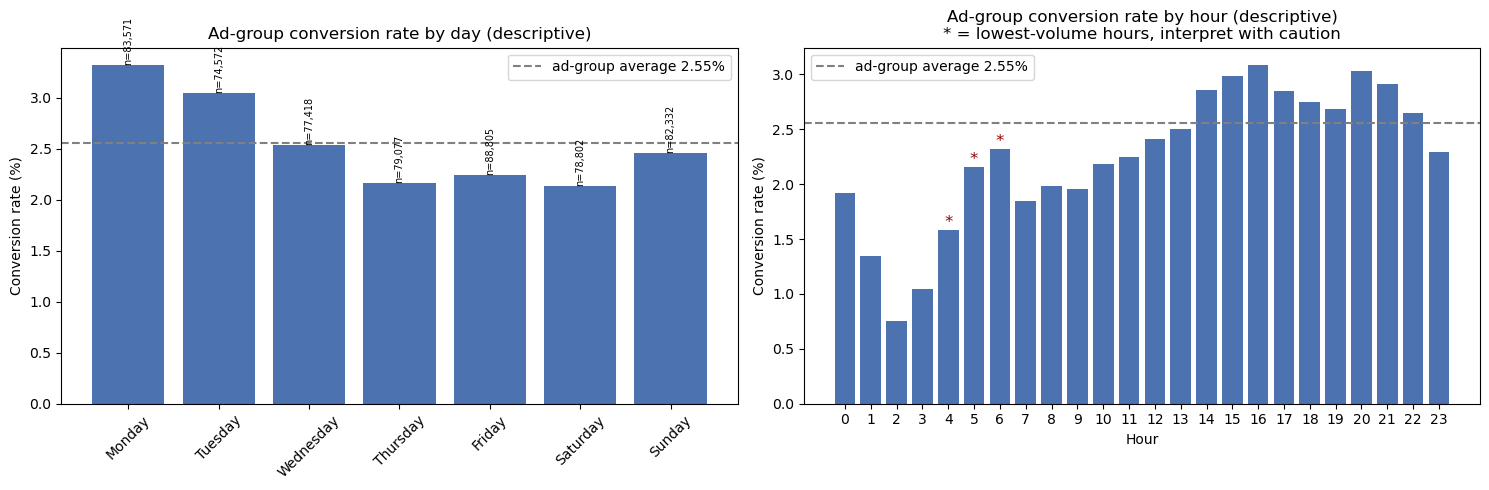

In [24]:
# --- Charts. Bar height is the rate, annotation carries the sample size
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(by_day.index.astype(str), by_day["rate_pct"], color="#4C72B0")
axes[0].axhline(p_ad_raw*100, ls="--", c="grey",
                label=f"ad-group average {p_ad_raw*100:.2f}%")
for i, (r, n) in enumerate(zip(by_day["rate_pct"], by_day["n"])):
    axes[0].text(i, r, f"n={n:,}", ha="center", va="bottom", fontsize=7, rotation=90)
axes[0].set_title("Ad-group conversion rate by day (descriptive)")
axes[0].set_ylabel("Conversion rate (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

axes[1].bar(by_hour.index, by_hour["rate_pct"], color="#4C72B0")
axes[1].axhline(p_ad_raw*100, ls="--", c="grey",
                label=f"ad-group average {p_ad_raw*100:.2f}%")
# Mark hours whose volume is too thin to read confidently
thin_hours = by_hour[by_hour["n"] < by_hour["n"].quantile(0.10)].index
for h in thin_hours:
    axes[1].text(h, by_hour.loc[h, "rate_pct"], "*", ha="center",
                 va="bottom", fontsize=12, color="darkred")
axes[1].set_title("Ad-group conversion rate by hour (descriptive)\n"
                  "* = lowest-volume hours, interpret with caution")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Conversion rate (%)")
axes[1].set_xticks(range(0, 24))
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "06_ad_group_timing_descriptive.png", dpi=150)
plt.show()

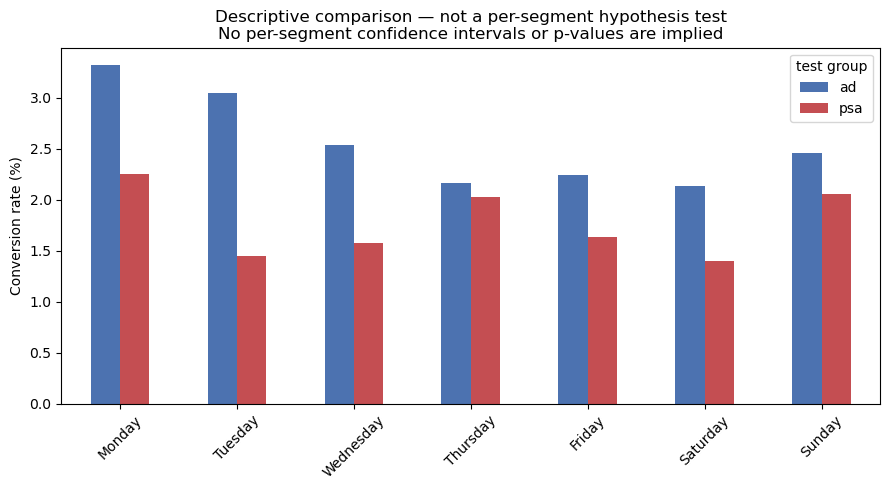

PSA rows per day, for context on why no per-segment test is run:
 most ads day
Monday       3502
Tuesday      2907
Wednesday    3490
Thursday     3905
Friday       3803
Saturday     2858
Sunday       3059


In [25]:
# --- The one fenced side-by-side view. No per-segment tests, by design
side = (df.groupby(["test group", "most ads day"], observed=True)["converted"]
          .mean().unstack(0) * 100)
side = side.reindex(DAY_ORDER)

ax = side.plot(kind="bar", figsize=(9, 5), color=["#4C72B0", "#C44E52"])
ax.set_title("Descriptive comparison — not a per-segment hypothesis test\n"
             "No per-segment confidence intervals or p-values are implied")
ax.set_ylabel("Conversion rate (%)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="test group")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_side_by_side_descriptive.png", dpi=150)
plt.show()

# PSA cell sizes are small enough that per-day PSA rates are unstable; state the
# numbers so the reader can see why no test is attached
psa_n = df[df["test group"] == "psa"].groupby("most ads day", observed=True).size()
print("PSA rows per day, for context on why no per-segment test is run:\n",
      psa_n.reindex(DAY_ORDER).to_string())

### Section 6 conclusion

Ad-group overall conversion rate: 2.5547%.

By day, conversion ranges from 2.1307% (Saturday) to 3.3241% (Monday), a spread
of 1.19 pp. By hour it ranges from 0.7570% (02:00) to 3.0893% (16:00), a spread
of 2.33 pp. Both spreads exceed the topline ad-vs-PSA lift of 0.7692 pp.

Grouped view:

| Block | Impressions | Share of ad group | Conversion rate |
|---|---|---|---|
| Mon-Tue | 158,143 | 28.0% | 3.192% |
| Thu-Sat | 246,684 | 43.7% | 2.183% |
| Hours 11-13 | 134,872 | 23.9% | 2.390% |
| Hours 14-16 | 122,597 | 21.7% | 2.970% |
| Hours 20-21 | 56,741 | 10.0% | 2.971% |

The largest-volume daypart (11:00-13:00) is not the best-performing one. Hours
14-16 and 20-21 convert roughly 0.58 pp higher on comparable or smaller volume.

Sample-size guardrails mattered here. The unfiltered top cell was Saturday 05:00
at 5.68%, resting on 5 conversions from 88 impressions, and the bottom two cells
recorded zero conversions from 88 and 79 impressions. Restricting to cells with
n >= 500 removes these artifacts and produces a stable ranking led by Tuesday
16:00 (4.56%, n=4,103), Monday 14:00 (4.49%, n=6,039) and Sunday 20:00 (4.37%,
n=3,733).

A precision note on the flag itself: the `thin` column is inherited from Section
5, where it was defined against PSA reference weight. It does not fully protect
ad-group rankings, as Saturday 06:00 (n=252, 13 conversions, 5.16%) shows. The
operative guardrail for this section is the n >= 500 filter, not the flag.

Causal limits of this section. `most ads hour` and `most ads day` record when a
user saw the most impressions, which is post-treatment and partly a function of
who the user is. The pattern above is therefore consistent with two very
different explanations: that these dayparts are genuinely more persuasive, or
that users who happen to be reachable in those windows convert more readily
regardless of timing. This analysis cannot separate them, so no budget
reallocation is recommended on this evidence alone. The correct next step is a
dedicated daypart experiment, which is proposed in the recommendations section.

## 7. Assumed-Cost Sensitivity Scenario (not derived from data)

Every figure in this section rests on assumptions that are not present in the
dataset. The data contains no cost column and no revenue column. Nothing here is
a measured result, and no number in this section should be quoted without the
assumption attached to it.

What is measured, and carried in from Section 5:
- standardized absolute lift: 0.7767 pp, 95% CI [0.6023, 0.9510] pp
- ad group size: 564,577 users

What is assumed:
- cost per thousand impressions (CPM), at three levels
- gross value per conversion, at three levels

Scope, per the ruling in Phase 2: this scenario runs on the topline standardized
lift only. It is not computed by daypart. An ROI figure is inherently a causal
claim, and the day/hour pattern in Section 6 is explicitly descriptive, so
running money through those segments would reintroduce the attribution problem
that section fenced off.

Primary output is the breakeven value per conversion, because it requires only
the cost assumption rather than both. The full ROI grid follows for completeness.

In [26]:
# --- Assumed-cost sensitivity. All inputs below are assumptions, not data
N_AD = int((df["test group"] == "ad").sum())
TOTAL_IMPRESSIONS = int(ad_df["total ads"].sum())

# Measured inputs carried in from Section 5
LIFT = {"low (CI lower)": 0.006023, "point": 0.007767, "high (CI upper)": 0.009510}

# ASSUMED: cost per 1,000 impressions, in currency units
CPM = {"low": 2.0, "mid": 5.0, "high": 10.0}

print(f"Ad group users:      {N_AD:,}")
print(f"Total ad impressions delivered: {TOTAL_IMPRESSIONS:,}")
print(f"Mean impressions per user:      {TOTAL_IMPRESSIONS/N_AD:.2f}\n")

inc = {k: v * N_AD for k, v in LIFT.items()}
for k, v in inc.items():
    print(f"incremental conversions, {k:16s} = {v:,.0f}")

# Breakeven needs only the cost assumption, so it is the most defensible output
rows = []
for ck, cpm in CPM.items():
    cost = TOTAL_IMPRESSIONS / 1000 * cpm
    for lk, conv in inc.items():
        rows.append({"cpm_assumed": cpm, "cost_assumed": cost,
                     "lift_scenario": lk, "incremental_conv": conv,
                     "breakeven_value_per_conv": cost / conv})

be = pd.DataFrame(rows)
print("\nBREAKEVEN VALUE PER CONVERSION (assumed CPM only)")
print(be.pivot(index="cpm_assumed", columns="lift_scenario",
               values="breakeven_value_per_conv").round(2).to_string())

Ad group users:      564,577
Total ad impressions delivered: 14,014,701
Mean impressions per user:      24.82

incremental conversions, low (CI lower)   = 3,400
incremental conversions, point            = 4,385
incremental conversions, high (CI upper)  = 5,369

BREAKEVEN VALUE PER CONVERSION (assumed CPM only)
lift_scenario  high (CI upper)  low (CI lower)  point
cpm_assumed                                          
2.0                       5.22            8.24   6.39
5.0                      13.05           20.61  15.98
10.0                     26.10           41.21  31.96


In [27]:
# --- Full ROI grid. Both axes are assumptions; read as a range, not a forecast
VALUE_PER_CONV = {"low": 5.0, "mid": 15.0, "high": 40.0}   # ASSUMED

grid = []
for ck, cpm in CPM.items():
    cost = TOTAL_IMPRESSIONS / 1000 * cpm
    for vk, val in VALUE_PER_CONV.items():
        gain = inc["point"] * val
        grid.append({"cpm": f"{ck} ({cpm})", "value_per_conv": f"{vk} ({val})",
                     "assumed_cost": cost, "assumed_gross_value": gain,
                     "net": gain - cost, "roi_pct": (gain - cost) / cost * 100})

g = pd.DataFrame(grid)
print("ROI GRID AT THE POINT LIFT ESTIMATE (0.7767 pp)")
print(g.pivot(index="cpm", columns="value_per_conv", values="roi_pct")
       .round(1).to_string())

# Repeat at the pessimistic bound: the decision has to survive this, not the point
grid_low = []
for ck, cpm in CPM.items():
    cost = TOTAL_IMPRESSIONS / 1000 * cpm
    for vk, val in VALUE_PER_CONV.items():
        gain = inc["low (CI lower)"] * val
        grid_low.append({"cpm": f"{ck} ({cpm})", "value_per_conv": f"{vk} ({val})",
                         "roi_pct": (gain - cost) / cost * 100})

print("\nROI GRID AT THE CI LOWER BOUND (0.6023 pp)")
print(pd.DataFrame(grid_low).pivot(index="cpm", columns="value_per_conv",
                                   values="roi_pct").round(1).to_string())

ROI GRID AT THE POINT LIFT ESTIMATE (0.7767 pp)
value_per_conv  high (40.0)  low (5.0)  mid (15.0)
cpm                                               
high (10.0)            25.2      -84.4       -53.1
low (2.0)             525.8      -21.8       134.7
mid (5.0)             150.3      -68.7        -6.1

ROI GRID AT THE CI LOWER BOUND (0.6023 pp)
value_per_conv  high (40.0)  low (5.0)  mid (15.0)
cpm                                               
high (10.0)            -2.9      -87.9       -63.6
low (2.0)             385.3      -39.3        82.0
mid (5.0)              94.1      -75.7       -27.2


### Section 7 conclusion — all figures assumption-dependent

Measured inputs: standardized lift 0.7767 pp (95% CI [0.6023, 0.9510]), ad group
564,577 users, 14,014,701 impressions delivered, 24.82 impressions per user.

Incremental conversions attributable to the campaign:
3,400 at the CI lower bound, 4,385 at the point estimate, 5,369 at the upper bound.

Breakeven gross value per conversion, which depends only on the CPM assumption:

| Assumed CPM | CI lower | Point | CI upper |
|---|---|---|---|
| 2 | 8.24 | 6.39 | 5.22 |
| 5 | 20.61 | 15.98 | 13.05 |
| 10 | 41.21 | 31.96 | 26.10 |

Read as: at an assumed CPM of 5, the campaign pays for itself only if one
conversion is worth more than roughly 16 units, and more than 21 units under the
pessimistic end of the lift interval. This is equivalent to the cost per
incremental conversion, since 14,014,701 impressions at CPM 5 cost 70,074 units
and produced an estimated 4,385 incremental conversions.

The ROI grid at the point estimate is positive in only 4 of 9 assumption
combinations, and at the CI lower bound in only 3 of 9. At mid assumptions
(CPM 5, value 15) ROI is -6.1% at the point estimate and -27.2% at the lower
bound.

The substantive conclusion of this section: a statistically overwhelming lift
(z = 7.37, p = 8.5e-14, relative lift 43%) is not sufficient to establish that
the campaign is worth running. Whether it pays depends entirely on values the
dataset does not contain. Only one cell in the grid changes sign across the lift
interval (CPM 10 with value 40, from +25.2% to -2.9%), which is the concrete
reason the interval rather than the point estimate is reported throughout.

Efficiency observation, independent of the cost assumptions: roughly 3,196
impressions were delivered per incremental conversion, at 24.82 impressions per
user. Frequency at that level is worth examining on its own terms.

## 8. Recommendation and proposed next test

The deliverable is not a reallocation call. The timing pattern in Section 6 sits
on a fork with two branches that imply opposite actions:

- the dayparts themselves are more persuasive, in which case shifting delivery
  toward 14:00-16:00, 20:00-21:00 and early week would raise conversions
- users reachable in those windows are simply more conversion-prone, in which
  case shifting delivery moves impressions without moving conversions

This analysis cannot distinguish them, because `most ads hour` and `most ads day`
are post-treatment and partly describe who the user is. Recommending a monitored
reallocation would not be a compromise between the branches; it would assume the
first one, which is the reading this analysis has explicitly declined to support.

Recommendation, in order:

1. Continue the ad campaign. The lift is 0.7767 pp standardized, 95% CI
   [0.6023, 0.9510] pp, robust across every specification tested in Section 5,
   and the decision survives the pessimistic bound of the interval.
2. Run a daypart experiment before changing any scheduling. Specification below.
3. Re-estimate ROI by daypart only if that experiment confirms a causal daypart
   effect. Until then no ROI figure is computed at segment level.

### Proposed daypart experiment

- Unit of randomization: user, assigned before first impression
- Arms: delivery restricted to the high-performing dayparts identified in
  Section 6, versus business-as-usual scheduling
- Primary metric: conversion rate per assigned user
- Secondary metric: impressions delivered per user, to confirm the arms differ in
  timing and not in exposure volume, which is the flaw that Section 5 had to
  correct for retrospectively
- Guardrail: assignment logged before delivery, so pre-treatment covariates exist
  and a genuine randomization check is possible. Their absence was the central
  limitation of this dataset.

In [28]:
# --- Sample size for the proposed daypart experiment, so the recommendation is
# --- an executable specification rather than a suggestion
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

BASELINE = p_ad_raw          # measured: current ad-group conversion rate
POWER, ALPHA = 0.80, 0.05    # conventional

print(f"Baseline conversion rate: {BASELINE*100:.4f}%\n")
print(f"{'MDE (pp)':>10} {'n per arm':>12} {'total n':>12}")
for mde_pp in [0.25, 0.50, 0.75, 1.00]:
    h = proportion_effectsize(BASELINE + mde_pp/100, BASELINE)
    n = NormalIndPower().solve_power(effect_size=h, power=POWER,
                                     alpha=ALPHA, ratio=1.0,
                                     alternative="two-sided")
    print(f"{mde_pp:>10.2f} {n:>12,.0f} {2*n:>12,.0f}")

Baseline conversion rate: 2.5547%

  MDE (pp)    n per arm      total n
      0.25       65,465      130,929
      0.50       17,083       34,167
      0.75        7,904       15,809
      1.00        4,618        9,236


### Experiment sizing

Baseline: 2.5547%, the measured ad-group conversion rate. Power 0.80, alpha 0.05,
two-sided, equal arms.

| MDE (pp) | n per arm | Total n |
|---|---|---|
| 0.25 | 65,465 | 130,929 |
| 0.50 | 17,083 | 34,167 |
| 0.75 | 7,904 | 15,809 |
| 1.00 | 4,618 | 9,236 |

The daypart differences observed in Section 6 span roughly 1.19 pp across days
and 2.33 pp across hours, so an MDE of 0.50 pp is more than sufficient to detect
an effect of the size suggested there. That requires 34,167 users in total, which
is 5.8% of the 588,101 users in this campaign. The proposed experiment is
therefore small relative to existing traffic, and the recommendation is
operationally realistic rather than theoretical.

Note that this sizing detects a daypart effect on conversion. It does not resolve
the fork on its own unless assignment is logged before delivery, which is why
that guardrail is listed above.